Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [2]:
import matplotlib.pyplot as plt
import requests
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

In [2]:
#do not re-execute this cell



# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)


In [4]:

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack=True)

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])
print(names)

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


/tmp/ipykernel_2194/3799718065.py:2: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack=True)


In [5]:
T90 = data[6, :].astype(float)
T90[T90 == -999] = np.nan
T90 = T90[~ np.isnan(T90)]
T90_err = data[7,:].astype(float)
T90_reshape = T90.reshape(-1, 1)



In [6]:
T90

array([2.04800e+01, 1.44000e-01, 1.37600e+01, ..., 3.13600e+00,
       2.08576e+02, 5.18400e+00], shape=(7982,))

the best bandwidth is 0.1181818181818182


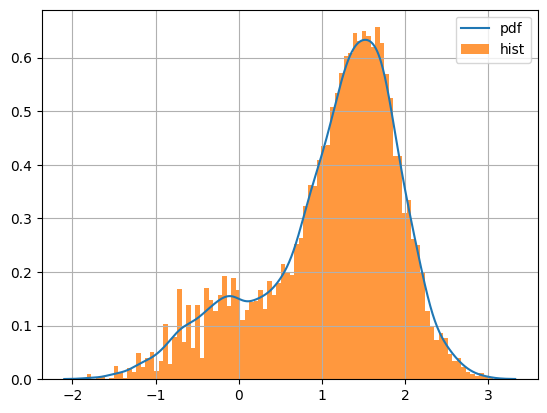

In [22]:
from sklearn.neighbors import KernelDensity


T90_log = np.log10(T90)
T90_log_reshape = T90_log.reshape(-1, 1)

x = np.linspace(np.min(T90_log), np.max(T90_log), 1000)
bandwidths = np.linspace(0.1, 1, 100)
grid = GridSearchCV(KernelDensity(), {'bandwidth': bandwidths})

grid.fit(T90_log_reshape)
best = grid.best_params_['bandwidth']

kd = KernelDensity(bandwidth=best)
kd.fit(T90_log_reshape)
pdf = kd.score_samples(x.reshape(-1, 1))

plt.plot(x, np.exp(pdf), label = 'pdf')
plt.hist(T90_log,bins= 100, alpha  = 0.8, density = True, label = 'hist' )
plt.grid()
plt.legend()
print(f'the best bandwidth is {best}')

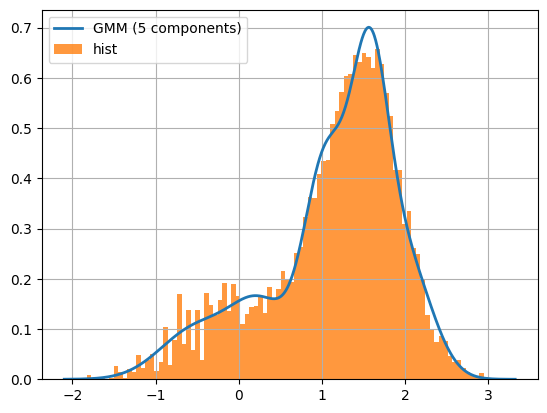

In [21]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5).fit(T90_log_reshape)
pdf_gmm = np.exp(gmm.score_samples(x.reshape(-1, 1)))

plt.plot(x, pdf_gmm, label='GMM (5 components)', linewidth=2)
plt.hist(T90_log, bins=100, alpha=0.8, density=True, label='hist')
plt.legend()
plt.grid()

(array([0.00231185, 0.        , 0.        , 0.        , 0.        ,
        0.00924738, 0.        , 0.00231185, 0.00462369, 0.        ,
        0.00231185, 0.0254303 , 0.01387107, 0.00231185, 0.02080661,
        0.01387107, 0.04854875, 0.02311845, 0.03930137, 0.0508606 ,
        0.01618292, 0.03467768, 0.10403304, 0.02774214, 0.07860274,
        0.1687647 , 0.06935536, 0.13871072, 0.05779613, 0.13871072,
        0.03930137, 0.17107655, 0.1479581 , 0.12715149, 0.15720548,
        0.19188316, 0.13639887, 0.18957131, 0.16645286, 0.11096857,
        0.12946333, 0.14333441, 0.14564625, 0.16645286, 0.13177518,
        0.18263578, 0.15720548, 0.18032393, 0.21500161, 0.19881869,
        0.194195  , 0.25199113, 0.26355036, 0.32365834, 0.36295971,
        0.36064786, 0.40919661, 0.43462691, 0.43693875, 0.50860596,
        0.53403626, 0.57102578, 0.60339161, 0.6080153 , 0.64500483,
        0.63113376, 0.64962852, 0.64038114, 0.61957453, 0.65656405,
        0.62651007, 0.56871393, 0.52478887, 0.41

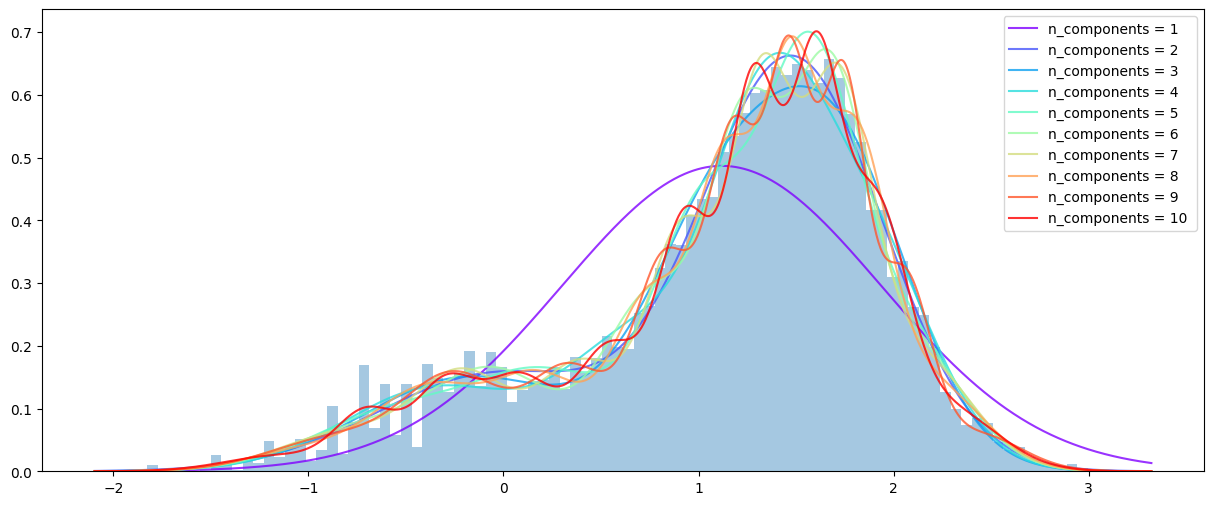

In [ ]:
from matplotlib import cm

Nmax = 10

colors = cm.rainbow(np.linspace(0, 1, Nmax))
plt.figure(figsize= (15, 6))

bic_score = []
aic_score = []

for n_comp in np.linspace(1, Nmax, Nmax):
    gmm = GaussianMixture(n_components= int(n_comp)).fit(T90_log_reshape)
    pdf_gmm = np.exp(gmm.score_samples(x.reshape(-1, 1)))
    
    bic_score.append(gmm.bic(T90_log_reshape))
    aic_score.append(gmm.aic(T90_log_reshape))

    plt.plot(x, pdf_gmm, alpha = 0.8, color = colors[int(n_comp) - 1], label=f'n_components = {int(n_comp)} ')

plt.legend()
plt.hist(T90_log, bins = 100, density = True, alpha = 0.4)

In [39]:
print(aic_score)

[19477.669191917008, 17804.44968256854, 17837.606744317956, 17870.36945407129, 17858.72659032603, 17870.26320189961, 17875.8674580894, 17893.391524196995, 17870.838350302187, 17878.7251671396]


In [41]:
print(f'lowest aic: {np.min(aic_score)} with {np.argmin(aic_score) +1} components')
print(f'lowest aic: {np.min(bic_score)} with {np.argmin(bic_score)+1} components')

lowest aic: 17804.44968256854 with 2 components
lowest aic: 17839.374403996582 with 2 components


are there two different classes?

In [60]:
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth

estimated_band = estimate_bandwidth(T90_log_reshape)
ms = MeanShift(bandwidth =  estimated_band, cluster_all= True, n_jobs = -1)
ms.fit(T90_log_reshape)


,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(0.5168373768035973)
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",False
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


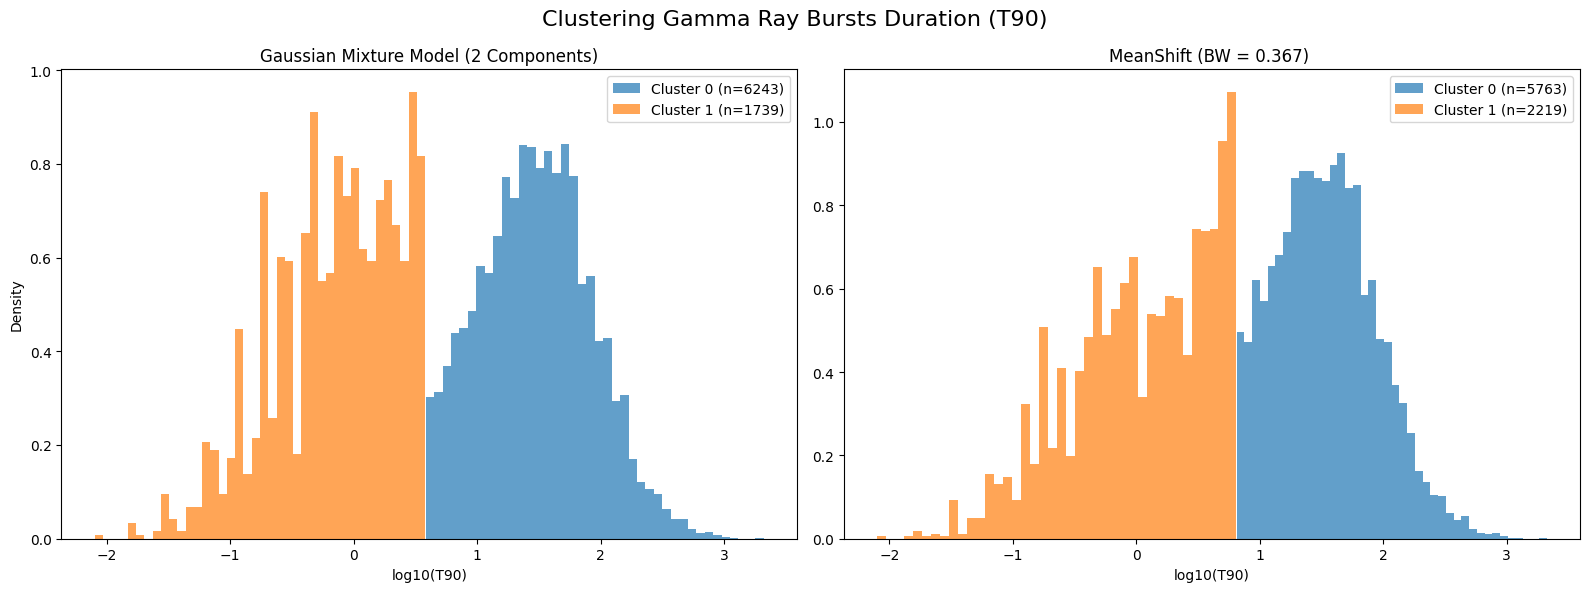

In [61]:
# Using the best bandwidth from your KDE grid search
gmm = GaussianMixture(n_components= 2).fit(T90_log_reshape)
gmm_labels = gmm.fit_predict(T90_log_reshape)

estimated_band =  0.3670847894466679
ms = MeanShift(bandwidth=estimated_band, cluster_all=True, n_jobs=-1)
ms_labels = ms.fit_predict(T90_log_reshape)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: GMM
for i in range(2):
    subset = T90_log[gmm_labels == i]
    axes[0].hist(subset, bins=40, alpha=0.7, label=f'Cluster {i} (n={len(subset)})', density=True)
axes[0].set_title("Gaussian Mixture Model (2 Components)")
axes[0].set_xlabel("log10(T90)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Subplot 2: MeanShift
unique_ms_labels = np.unique(ms_labels)
# Limit to top 5 clusters by size to avoid legend clutter if there are too many
cluster_sizes = [len(T90_log[ms_labels == lbl]) for lbl in unique_ms_labels]
top_clusters = np.array(unique_ms_labels)[np.argsort(cluster_sizes)[::-1]][:5]

for lbl in top_clusters:
    subset = T90_log[ms_labels == lbl]
    axes[1].hist(subset, bins=40, alpha=0.7, label=f'Cluster {lbl} (n={len(subset)})', density=True)
axes[1].set_title(f"MeanShift (BW = {estimated_band:.3f}) ")
axes[1].set_xlabel("log10(T90)")
axes[1].legend()

plt.suptitle("Clustering Gamma Ray Bursts Duration (T90)", fontsize=16)
plt.tight_layout()